# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

In [3]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
El dataset contiene 40,000 registros y 9 columnas sin valores nulos. 
La columna 'date' esta en formato 'object' el cual convertiremos a 'datetime'.
El resto de las columnas muestran tener el tipo de dato correcto.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

<div class="alert alert-block alert-success">
<b>Exploracion Inicial</b> <a class="tocSkip"></a>

Excelente! Utilizaste correctamente head() e info() para obtener una primera vista del dataset. 

</div>

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
print("Total de usuarios únicos:", df['user_id'].nunique())

Total de usuarios únicos: 40000


 **Variable `date`**  
Explorar rango de fechas


In [7]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"]== 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type', 'converted']:
    print(f"\n{col}:\n", df[col].value_counts())
    


Conteo de categorías:

landing:
 B    20018
A    19982
Name: landing, dtype: int64

region:
 Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
 Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
 Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
 Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

converted:
 0    34294
1     5706
Name: converted, dtype: int64


<div class="alert alert-block alert-success">
<b>Validacion de Variables</b> <a class="tocSkip"></a>

Revisaste correctamente las variables clave usando describe() y value_counts(). Esto asegura que los datos estan en el formato esperado antes de continuar con el analisis estadistico.

</div>

✍️ **Comentario**: 

- Toda las columnas tienen valores esperados y sin anomalias. La división A/B es equilibrada de usuarios con una diferencia de 32 usuarios (50/50). 
- La tasa de conversión global es del 14.3% (5,706 usuarios).
- El gasto promedio entre convertidos es de $63.37, con   alta   variabilidad (std $30.90).


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"] #completa el código
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"] #completa el código

# Verificar cantidad de datos que tiene cada grupo
print ("Usuarios convertidos en página A:", len(gasto_A)) 
print ("Usuarios convertidos en página B:",len(gasto_B))

Usuarios convertidos en página A: 2512
Usuarios convertidos en página B: 3194


<div class="alert alert-block alert-success">
<b>Filtro de Clientes y Gasto Promedio</b> <a class="tocSkip"></a>

Filtraste correctamente solo los usuarios convertidos (converted = 1).

</div>

In [13]:
print(f"Gasto promedio página A: ${gasto_A.mean():.2f}")
print(f"Gasto promedio página B: ${gasto_B.mean():.2f}")

Gasto promedio página A: $61.09
Gasto promedio página B: $68.75


### Prueba T de Welch 

**Hipótesis:**
- **Hipótesis nula (H₀):*El gasto promedio de la página A es igual al de la página B**
- **Hipótesis alternativa (H₁):*El gasto promedio de la página A es diferente al de la página B**

<div class="alert alert-block alert-success">
<b>Definicion de Hipotesis</b> <a class="tocSkip"></a>

Las hipotesis nula (H0) y alternativa (H1) estan correctamente formuladas y son coherentes con el objetivo del analisis. Una hipotesis bien planteada es la base de cualquier prueba estadistica rigurosa.

</div>

In [14]:
# Aplicar prueba

from scipy.stats import ttest_ind

stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)
print(f"\nEstadístico t: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Visualizar resultados
alpha = 0.05
if p_value < alpha:
    print("Se RECHAZA H₀ — hay diferencia significativa en el gasto")
else:
    print("No se rechaza H₀ — no hay diferencia significativa en el gasto")



Estadístico t: -9.4810
Valor p: 0.0000
Se RECHAZA H₀ — hay diferencia significativa en el gasto


<div class="alert alert-block alert-danger">
<b>Prueba de Levene</b> <a class="tocSkip"></a>

No se aplico la prueba de Levene. Antes de ejecutar el t-test, es necesario verificar si las varianzas de ambos grupos son homogeneas. Si son iguales, se usa equal_var=True; si son distintas (p-value de Levene menor a 0.05), se debe usar equal_var=False, que corresponde a la prueba de Welch.

<div class="alert alert-block alert-success">
<b>Test Estadistico — t-test</b> <a class="tocSkip"></a>

Aplicaste correctamente el t-test y reportaste tanto el estadistico t_stat como el p-value.

</div>
    
</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (p = 0.0000 < 0.05).

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en el gasto promedio entre ambas páginas. La página B genera un mayor gasto promedio por usuario convertido que la página A.

<div class="alert alert-block alert-success">
<b>Interpretacion — Gasto Promedio</b> <a class="tocSkip"></a>

Muy bien! La interpretacion del resultado es clara y esta redactada en terminos de negocio. 

Efectivamente debemos rechazar la hipótesis nula.

Explicaste correctamente el significado del p-value y lo vinculaste a una conclusion accionable sobre las landings.
</div>

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Chi-cuadrada. 

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión de la página A es igual a la tasa de conversión de la página B (no existe asociación entre la versión de la página y la conversión).
- **Hipótesis alternativa (H₁):** La tasa de conversión de la página a es diferente a la tasa de conversión de la página B (existe asociación entre la versión de página y la conversión).

In [15]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total = df.groupby('landing')['converted'].count()

# Tasa de conversión 
tasa = convertidos/total * 100

print("Usuarios convertidos por página:\n", convertidos)
print("Total de usuarios por página:\n", total)
print("Tasa de conversión por pagina(%):\n",tasa.round(2))

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64
Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64
Tasa de conversión por pagina(%):
 landing
A    12.57
B    15.96
Name: converted, dtype: float64


<div class="alert alert-block alert-success">
<b>Calculo de Metricas — Tasa de Conversion</b> <a class="tocSkip"></a>

Calculaste correctamente la tasa de conversion para cada landing. Las metricas son precisas y estan bien presentadas, lo que facilita la comparacion entre los grupos del experimento A/B.

</div>

In [16]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Crear tabla
tabla_contingencia= pd.crosstab (df["landing"],  df["converted"])
print("Tabla of contingencia:\n", tabla_contingencia)

# Aplicar prueba
stat, p_value, dof, expected = chi2_contingency(tabla_contingencia)

# Visualizar resultados
print(f"\nEstadistíco Chi-cuadrado:{stat:.4f}")
print(f"\Valor p: {p_value:.4f}")

alpha = 0.05
if p_value <alpha:
       print("Se rechaza H₀ — hay diferencia significativa en la tasa de conversión")
else:
       print("No se rechaza H₀ — no hay diferencia significativa en la tasa de conversión")


Tabla of contingencia:
 converted      0     1
landing               
A          17470  2512
B          16824  3194

Estadistíco Chi-cuadrado:93.3748
\Valor p: 0.0000
Se rechaza H₀ — hay diferencia significativa en la tasa de conversión


<div class="alert alert-block alert-success">
<b>Test Estadistico </b> <a class="tocSkip"></a>

Aplicaste correctamente el test para comparar las tasas de conversion entre las dos landings.

Efectivamente, rechazamos la hipótesis nula ya que hay evidencia de una dirferencia. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la Hipótesis nula ya que hay una diferencia significativa en la tasa de conversión (p = 0.0000 < 0.05).

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en la tasa de conversión entre ambas páginas. La página B convierte al 16.0% de sus usuarios, mientras que la página A solo al 12.6%. Esto representa una mejora de 3.4 puntos porcentuales a favor de la página B, lo cual es relevante para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi-cuadrada de independencia.

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son independientes (no existe asociación entre ellas).
- **Hipótesis alternativa (H₁):** La fuente de tráfico y la conversión no son independientes (existe asociación entre ellas).

In [17]:
# Aplicar prueba
from scipy.stats import chi2_contingency

# Tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print("Tabla de contingencia:\n", tabla)

# Aplicar prueba
stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"\nEstadístico Chi²: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Se rechaza H₀ — existe asociación entre fuente de tráfico y conversión")
else:
    print("No se rechaza H₀ — no existe asociación entre fuente de tráfico y conversión")


Tabla de contingencia:
 converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico Chi²: 8.6621
Valor p: 0.0341
Se rechaza H₀ — existe asociación entre fuente de tráfico y conversión


<div class="alert alert-block alert-success">
<b>Interpretacion — Trafico y Conversion</b> <a class="tocSkip"></a>

El insight extraido sobre la relacion entre la fuente de trafico y la conversion es claro. Podemos decir que hay evidencia de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula porque existe asociación entre fuente de tráfico y conversión (p = 0.0341 < 0.05).

**Interpretación de negocio:**  
Existe una asociación estadisticamente significativa entre la fuente de tráfico y la conversión, aunque la diferencia entre canales es pequeña. En email representaria el 15% y Ads el 14.7%, los cuales serian los canales más efectivos, y por otro lado organic con un 13.8% tiene la tasa más baja a pesar de traer el mayor volumen de usuarios. 


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-cuadrada de independencia.

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuarios y la conversión son independientes (no hay relación significativa).
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre el tipo de usuario y conversión. 

In [18]:
#Tabla de contingencia entre tipo de usuario y conversión 
tabla_user_type = pd.crosstab(df['user_type'], df['converted'])
print("Tabla de contingencia:")
print(tabla_user_type)

Tabla de contingencia:
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [19]:
# Aplicar prueba
from scipy.stats import chi2_contingency 
stat, p_value, dof, expected = chi2_contingency(tabla_user_type)

print(f"Estadistico Chi²: {stat:.4f}") 
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
      print("Se rechaza H₀ — existe una asociación significativa entre el tipo de usuario y la conversión")
else:
     print("No se rechaza H₀ — no hay evidencia de asociación significativa")

# Cálculo de porcentajes para interpretación
conversion_por_tipo = (tabla_user_type[1] / tabla_user_type.sum(axis=1)) * 100
print("\nTasa de conversión por tipo de usuario (%):")
print(conversion_por_tipo.round(2))


Estadistico Chi²: 0.5135
Valor p: 0.4736
No se rechaza H₀ — no hay evidencia de asociación significativa

Tasa de conversión por tipo de usuario (%):
user_type
Nuevo         14.36
Recurrente    14.09
dtype: float64


<div class="alert alert-block alert-success">
<b>Interpretacion — Nuevos vs. Recurrentes</b> <a class="tocSkip"></a>

Excelente! Comparaste efectivamente el comportamiento de conversion entre usuarios nuevos y recurrentes, y tradujiste los hallazgos en una conclusion con valor estrategico. 

No rechazamos la hipótesis en este caso, ya que no hay evidencia suficiente de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (p_value=0.473> 0.05). 

**Interpretación de negocio:**  
No existe una asociación estadistícamente significativa entre el tipo de usuario y la conversión. Esto indica que tanto los usuarios Nuevos como los Recurrentes se están comportando de manera similar frente a la página.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

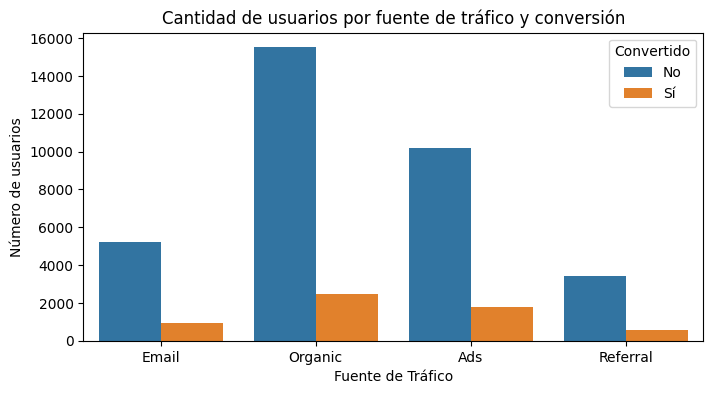

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="traffic_source", hue="converted")
plt.title("Cantidad de usuarios por fuente de tráfico y conversión")
plt.xlabel("Fuente de Tráfico")
plt.ylabel("Número de usuarios")
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.show()


✍️ **Comentario**: 
El gráfico compara el volumen de usuarios que no convirtieron (azul oscuro) frente a los que sí lo hicieron (verde) en cuatro canales distintos: Email, Organic, Ads y Referral. 

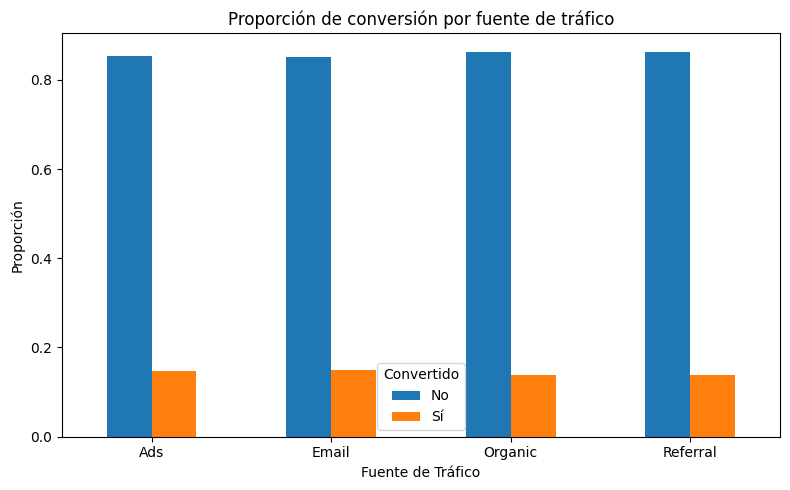

In [21]:
# Proporción de conversión por fuente de tráfico
prop_traffic = df.groupby('traffic_source')['converted'].value_counts(normalize=True).unstack()
prop_traffic.columns = ['No', 'Sí']

prop_traffic.plot(kind='bar', figsize=(8,5))
plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend(title='Convertido')
plt.tight_layout()
plt.show()


✍️ **Comentario**: El gráfico muestra que las proporciones de conversión son similares entre todas las fuentes de tráfico, oscilando entre el 13.8% y 15.0%. Aunque las diferencias son pequeñas, Email y Ads presentan una proporción ligeramente mayor de usuarios convertidos. Esto refuerza el resultado de la prueba Chi-cuadrada: existe asociación entre la fuente de tráfico y la conversión, pero el efecto es moderado.

### Relación entre el tipo de usuario y la conversión

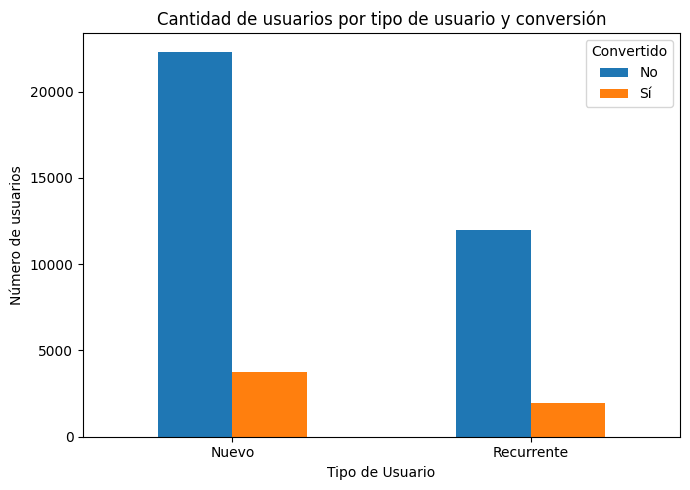

In [22]:

conteo_user = df.groupby('user_type')['converted'].value_counts().unstack()
conteo_user.columns = ['No', 'Sí']

conteo_user.plot(kind='bar', figsize=(7,5))
plt.title('Cantidad de usuarios por tipo de usuario y conversión')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=0)
plt.legend(title='Convertido')
plt.tight_layout()
plt.show()

✍️ **Comentario**: 
Los usuarios Nuevos generan más conversiones simplemente porque son más en volumen (26,033 vs 13,967). Sin embargo, esto no necesariamente indica mayor efectividad.

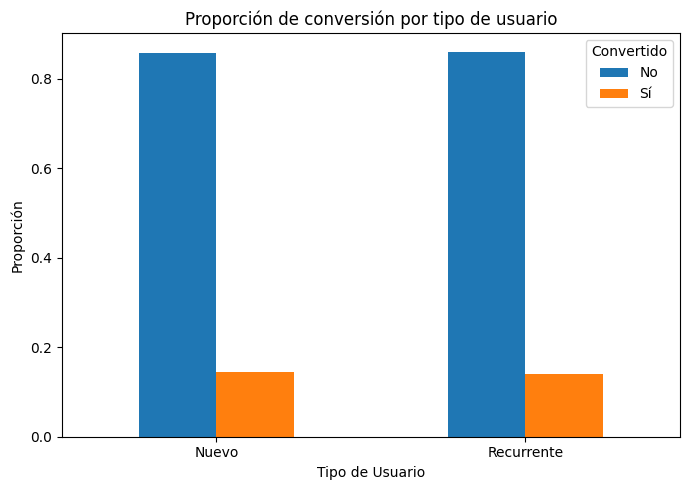

In [23]:
prop_user = df.groupby('user_type')['converted'].value_counts(normalize=True).unstack()
prop_user.columns = ['No', 'Sí']

prop_user.plot(kind='bar', figsize=(7,5))
plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend(title='Convertido')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Graficos Clave</b> <a class="tocSkip"></a>

Los graficos son claros, informativos y estan bien construidos. 

Además, los comentarios y conclusiones son muy buenos.Excelente trabajo!

</div>

✍️ **Comentario**: 
Las proporciones de conversión son prácticamente iguales entre usuarios Nuevos (14.5%) y Recurrentes (14.1%), lo que sugiere que el tipo de usuario no tiene un impacto relevante en la probabilidad de conversión. 

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La pagina B generó un gasto promedio significativamente mayor que la página A entre los usuarios convertidos.  
- La prueba estadistíca T de welch mostró un p_value=0.000, diferencia estadísticamente significativa. Es decir, el cambio es real y provocado por la página, no por el azar.
- **Interpretación:** La página B produce mayor valor económico por cliente.

<br>

**Tasa de conversión:** 
- La página B presenta una tasa de conversión del 16% contra la página A con un porcentaje de 12.6%.
- La prueba chi-cuadrada mostró p_value=0.000, diferencia estadisticamente significativa Ya que confirma que esta diferencia de 3.4 puntos porcentuales no es producto del azar. 
- **Interpretación:** La página B convierte más usuarios en clientes.

---

#### 📊 **Segmentación por fuente de tráfico**
- Email (15.0%) y Ads (14.7%) son los canales más efectivos, Organic trae el mayor volumen pero la tasa más baja (13.8%).
- **Interpretación:** Email y Ads presentan tasas ligeramente superiores, mientras que Organic, a pesar de traer el mayor volumen de usuarios, tiene la tasa de conversión más baja.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Nuevos (14.5%) y Recurrentes (14.1%) convierten casi igual.
- **Interpretación:** El tipo de usuario no determina la probabilidad de conversión.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
-Implementar la página B como versión definitiva, ya que supera a A en conversión y gasto.

-Priorizar campañas de Email y Ads sobre tráfico Organic para maximizar conversiones.

-No segmentar estrategia por tipo de usuario, ya que ambos convierten de forma similar.

<div class="alert alert-block alert-success">
<b>Sintesis del Experimento</b> <a class="tocSkip"></a>

El resumen del experimento es claro y completo: describe el objetivo, el diseno y las variables clave de forma concisa.

Integraste correctamente los resultados en una interpretacion coherente y basada en evidencia. La narrativa conecta los hallazgos estadisticos con implicaciones concretas para el negocio de forma efectiva.
    
</div>